# Laboratorio 2 — Redes Neuronales Convolucionales

**Objetivo:** comparar un MLP y una CNN para clasificar MNIST. El notebook separa entrenamiento, validación y test para evitar contaminación durante la búsqueda de hiperparámetros.

## 1. Configuración y reproducibilidad

In [1]:
import random
import time
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
BATCH_SIZE = 128
EPOCHS = 10
DATA_DIR = 'data'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Dispositivo: {device}')

PyTorch: 2.13.0+cu130
Dispositivo: cuda


## 2. Carga, exploración y preparación de MNIST

MNIST contiene 60,000 imágenes de entrenamiento y 10,000 de test. Cada imagen es monocromática, de 28×28 píxeles, y representa una de diez clases (los dígitos 0–9). Se reserva el 10% del conjunto de entrenamiento para validación.

Train original: 60,000 | Train: 54,000 | Validación: 6,000 | Test: 10,000
Clases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Rango original de píxeles: [0, 255]
Forma tras ToTensor: torch.Size([1, 28, 28])


/tmp/ipykernel_139993/3027374966.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(train_full.targets)


,cantidad
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


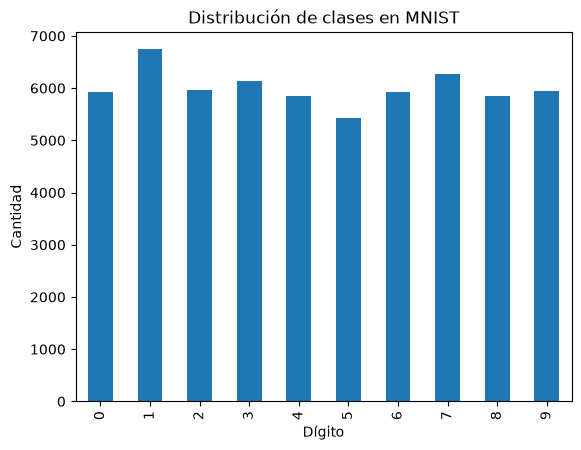

In [2]:
MEAN, STD = (0.1307,), (0.3081,)
transform = transforms.Compose([
    transforms.ToTensor(),                 # [0, 255] -> [0, 1]
    transforms.Normalize(MEAN, STD),       # normalización de MNIST
])

train_full = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)
train_dataset, val_dataset = random_split(
    train_full, [54_000, 6_000],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

labels = np.array(train_full.targets)
class_counts = pd.Series(labels).value_counts().sort_index()
print(f'Train original: {len(train_full):,} | Train: {len(train_dataset):,} | Validación: {len(val_dataset):,} | Test: {len(test_dataset):,}')
print(f'Clases: {class_counts.index.tolist()}')
print(f'Rango original de píxeles: [{train_full.data.min().item()}, {train_full.data.max().item()}]')
print(f'Forma tras ToTensor: {train_full[0][0].shape}')
display(class_counts.rename('cantidad').to_frame())
class_counts.plot(kind='bar', title='Distribución de clases en MNIST', xlabel='Dígito', ylabel='Cantidad')
plt.show()

# El conteo por clase es parecido, así que el dataset está aproximadamente balanceado.
# La normalización centra y escala las entradas, lo que suele estabilizar y acelerar la optimización.

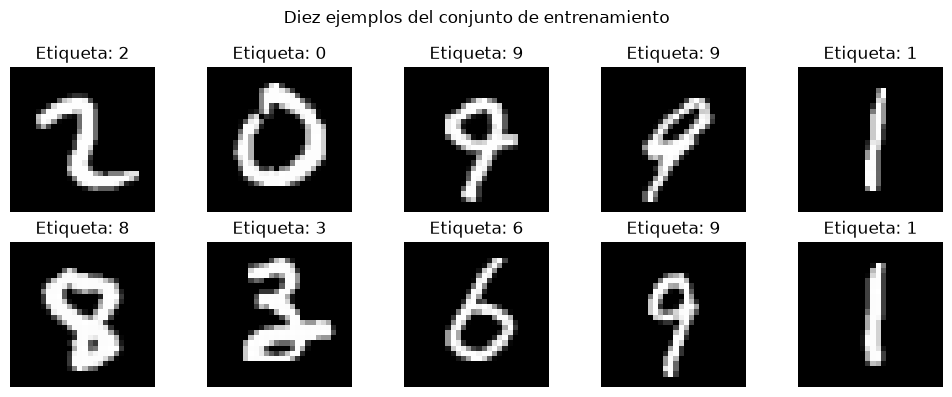

In [3]:
images, labels_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flat, images[:10], labels_batch[:10]):
    image_to_show = image * STD[0] + MEAN[0]  # desnormalizar únicamente para la gráfica
    ax.imshow(image_to_show.squeeze(), cmap='gray')
    ax.set_title(f'Etiqueta: {label.item()}')
    ax.axis('off')
plt.suptitle('Diez ejemplos del conjunto de entrenamiento')
plt.tight_layout()
plt.show()

## 3. Investigación: capas y conceptos de PyTorch

| Elemento | Propósito y parámetros relevantes |
|---|---|
| `nn.Conv2d` | Aplica filtros aprendibles para detectar patrones locales. Parámetros: `in_channels`, `out_channels`, `kernel_size`, `stride`, `padding` y `bias`. |
| `nn.MaxPool2d` | Reduce la resolución tomando el máximo de cada región. Parámetros: `kernel_size`, `stride` y `padding`. |
| `nn.AvgPool2d` | Reduce la resolución calculando el promedio de cada región. Parámetros: `kernel_size`, `stride` y `padding`. |
| `nn.BatchNorm2d` | Normaliza activaciones por canal; puede estabilizar el entrenamiento. Parámetros: `num_features`, `eps`, `momentum` y `affine`. |
| `nn.Flatten` | Convierte mapas de características en un vector para capas densas. Parámetros: `start_dim` y `end_dim`. |
| `nn.CrossEntropyLoss` | Pérdida para clasificación multiclase; recibe logits, no valores tras softmax. Parámetros: `weight`, `reduction` y `label_smoothing`. |

Un **tensor** es un arreglo multidimensional de PyTorch con forma, tipo de dato y dispositivo. El **campo receptivo** es la región de la imagen de entrada que puede influir en una activación; crece al apilar convoluciones y pooling. Las CNN suelen tener menos parámetros que un MLP equivalente porque conectan localmente y comparten el mismo filtro en todas las posiciones espaciales.

## 4. Funciones reutilizables

Se usa F1 weighted como métrica principal de selección. Si hay empate, se compara accuracy y después el número de parámetros.

In [4]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item() * y.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred,
    }


def train_model(model, lr, weight_decay, epochs=EPOCHS):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': []}
    best_state, best_val = None, None
    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * y.size(0)

        val_metrics = evaluate(model, val_loader, criterion)
        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['val_loss'].append(val_metrics['loss'])
        if best_val is None or val_metrics['f1_weighted'] > best_val['f1_weighted']:
            best_state, best_val = deepcopy(model.state_dict()), val_metrics
        print(f'Época {epoch + 1:02d}/{epochs} | train loss={history["train_loss"][-1]:.4f} | val loss={val_metrics["loss"]:.4f} | val F1={val_metrics["f1_weighted"]:.4f}')

    model.load_state_dict(best_state)
    return model, history, best_val, time.perf_counter() - start


def plot_loss(histories, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for experiment_id, history in histories.items():
        epochs = range(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs, history['train_loss'], marker='o', label=experiment_id)
        axes[1].plot(epochs, history['val_loss'], marker='o', label=experiment_id)
    axes[0].set(title=f'{title}: pérdida de entrenamiento', xlabel='Época', ylabel='Loss')
    axes[1].set(title=f'{title}: pérdida de validación', xlabel='Época', ylabel='Loss')
    for ax in axes: ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout()


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta real')
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 5. Arquitecturas

In [5]:
class MLPClassifier(nn.Module):
    """MLP configurable, siguiendo la estructura del Laboratorio 1."""

    def __init__(self, input_dim=28 * 28, hidden_layers=(256, 128),
                 activation='relu', dropout=0.2, batch_norm=False):
        super().__init__()
        activations = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'tanh': nn.Tanh,
        }
        if activation not in activations:
            raise ValueError(f'Activación no válida: {activation}')

        layers = [nn.Flatten()]
        previous_dim = input_dim
        for neurons in hidden_layers:
            layers.append(nn.Linear(previous_dim, neurons))
            if batch_norm:
                layers.append(nn.BatchNorm1d(neurons))
            layers.append(activations[activation]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = neurons

        # Diez logits, uno por cada dígito; CrossEntropyLoss aplica la normalización necesaria.
        layers.append(nn.Linear(previous_dim, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class CNN(nn.Module):
    def __init__(self, channels=(32, 64), dropout=0.25, use_batchnorm=True, avg_pool=False):
        super().__init__()
        c1, c2 = channels
        pool = nn.AvgPool2d if avg_pool else nn.MaxPool2d
        block_1 = [nn.Conv2d(1, c1, kernel_size=3, padding=1)]
        if use_batchnorm: block_1.append(nn.BatchNorm2d(c1))
        block_1.extend([nn.ReLU(), pool(2)])
        block_2 = [nn.Conv2d(c1, c2, kernel_size=3, padding=1)]
        if use_batchnorm: block_2.append(nn.BatchNorm2d(c2))
        block_2.extend([nn.ReLU(), pool(2)])
        self.features = nn.Sequential(*block_1, *block_2)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(c2 * 7 * 7, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 10))

    def forward(self, x):
        return self.classifier(self.features(x))

# Verificación de dimensiones: el MLP aplana a 784 y la CNN conserva N×1×28×28 hasta Flatten.
sample_x, _ = next(iter(train_loader))
print('Entrada:', sample_x.shape)
print('Salida MLP:', MLPClassifier()(sample_x).shape)
print('Salida CNN:', CNN()(sample_x).shape)

Entrada: torch.Size([128, 1, 28, 28])
Salida MLP: torch.Size([128, 10])
Salida CNN: torch.Size([128, 10])


## 6. Experimentos: MLP y CNN

Se entrenan cinco configuraciones por arquitectura. La configuración final se selecciona exclusivamente con F1 weighted en validación. Modificar una o dos variables a la vez permite relacionar cambios de hiperparámetros con su efecto.

In [6]:
experiments = [
    {'id': 'MLP-01', 'architecture': 'MLP', 'model_kwargs': {'hidden_layers': (256, 128), 'activation': 'relu', 'dropout': .2, 'batch_norm': False}, 'lr': 1e-3, 'weight_decay': 1e-4, 'notes': 'Baseline'},
    {'id': 'MLP-02', 'architecture': 'MLP', 'model_kwargs': {'hidden_layers': (256, 128), 'activation': 'relu', 'dropout': .2, 'batch_norm': False}, 'lr': 3e-4, 'weight_decay': 1e-4, 'notes': 'Menor learning rate'},
    {'id': 'MLP-03', 'architecture': 'MLP', 'model_kwargs': {'hidden_layers': (512, 256), 'activation': 'relu', 'dropout': .2, 'batch_norm': False}, 'lr': 1e-3, 'weight_decay': 1e-4, 'notes': 'Capas más anchas'},
    {'id': 'MLP-04', 'architecture': 'MLP', 'model_kwargs': {'hidden_layers': (256, 128), 'activation': 'relu', 'dropout': .4, 'batch_norm': False}, 'lr': 1e-3, 'weight_decay': 1e-4, 'notes': 'Mayor dropout'},
    {'id': 'MLP-05', 'architecture': 'MLP', 'model_kwargs': {'hidden_layers': (256, 128), 'activation': 'leaky_relu', 'dropout': .2, 'batch_norm': True}, 'lr': 1e-3, 'weight_decay': 1e-3, 'notes': 'LeakyReLU, BatchNorm y mayor weight decay'},
    {'id': 'CNN-01', 'architecture': 'CNN', 'model_kwargs': {'channels': (32, 64), 'dropout': .25, 'use_batchnorm': True, 'avg_pool': False}, 'lr': 1e-3, 'weight_decay': 1e-4, 'notes': 'Baseline'},
    {'id': 'CNN-02', 'architecture': 'CNN', 'model_kwargs': {'channels': (32, 64), 'dropout': .25, 'use_batchnorm': True, 'avg_pool': False}, 'lr': 3e-4, 'weight_decay': 1e-4, 'notes': 'Menor learning rate'},
    {'id': 'CNN-03', 'architecture': 'CNN', 'model_kwargs': {'channels': (64, 128), 'dropout': .25, 'use_batchnorm': True, 'avg_pool': False}, 'lr': 1e-3, 'weight_decay': 1e-4, 'notes': 'Más canales'},
    {'id': 'CNN-04', 'architecture': 'CNN', 'model_kwargs': {'channels': (32, 64), 'dropout': .4, 'use_batchnorm': True, 'avg_pool': False}, 'lr': 1e-3, 'weight_decay': 1e-3, 'notes': 'Mayor regularización'},
    {'id': 'CNN-05', 'architecture': 'CNN', 'model_kwargs': {'channels': (32, 64), 'dropout': .25, 'use_batchnorm': False, 'avg_pool': True}, 'lr': 1e-3, 'weight_decay': 1e-4, 'notes': 'AvgPool sin BatchNorm'},
]

trained_models, histories, rows = {}, {}, []
for exp in experiments:
    print(f'\n===== {exp["id"]}: {exp["notes"]} =====')
    model_cls = MLPClassifier if exp['architecture'] == 'MLP' else CNN
    model = model_cls(**exp['model_kwargs'])
    model, history, best_val, seconds = train_model(model, exp['lr'], exp['weight_decay'])
    trained_models[exp['id']] = model
    histories[exp['id']] = history
    rows.append({
        'id': exp['id'], 'architecture': exp['architecture'], 'hyperparameters': f'{exp["model_kwargs"]}, lr={exp["lr"]}, weight_decay={exp["weight_decay"]}',
        'epochs': EPOCHS, 'train_loss_final': history['train_loss'][-1], 'val_loss_final': history['val_loss'][-1],
        'val_accuracy': best_val['accuracy'], 'val_precision_weighted': best_val['precision_weighted'],
        'val_recall_weighted': best_val['recall_weighted'], 'val_f1_weighted': best_val['f1_weighted'],
        'trainable_parameters': count_trainable_parameters(model), 'training_seconds': seconds, 'notes': exp['notes'],
    })

results_df = pd.DataFrame(rows).sort_values(['architecture', 'val_f1_weighted'], ascending=[True, False])
display(results_df.round(4))
results_df.to_csv('resultados_iteraciones.csv', index=False)


===== MLP-01: Baseline =====
Época 01/10 | train loss=0.3334 | val loss=0.1528 | val F1=0.9548
Época 02/10 | train loss=0.1437 | val loss=0.1110 | val F1=0.9675
Época 03/10 | train loss=0.1071 | val loss=0.1019 | val F1=0.9711
Época 04/10 | train loss=0.0849 | val loss=0.0913 | val F1=0.9746
Época 05/10 | train loss=0.0741 | val loss=0.0887 | val F1=0.9736
Época 06/10 | train loss=0.0624 | val loss=0.0811 | val F1=0.9770
Época 07/10 | train loss=0.0561 | val loss=0.0741 | val F1=0.9790
Época 08/10 | train loss=0.0529 | val loss=0.0715 | val F1=0.9792
Época 09/10 | train loss=0.0478 | val loss=0.0814 | val F1=0.9800
Época 10/10 | train loss=0.0415 | val loss=0.0932 | val F1=0.9755

===== MLP-02: Menor learning rate =====
Época 01/10 | train loss=0.5080 | val loss=0.2376 | val F1=0.9263
Época 02/10 | train loss=0.2141 | val loss=0.1663 | val F1=0.9469
Época 03/10 | train loss=0.1572 | val loss=0.1366 | val F1=0.9581
Época 04/10 | train loss=0.1244 | val loss=0.1182 | val F1=0.9628
Época

,id,architecture,hyperparameters,epochs,train_loss_final,val_loss_final,val_accuracy,val_precision_weighted,val_recall_weighted,val_f1_weighted,trainable_parameters,training_seconds,notes
7,CNN-03,CNN,"{'channels': (64, 128), 'dropout': 0.25, 'use_...",10,0.0216,0.0379,0.9915,0.9915,0.9915,0.9915,879114,102.2667,Más canales
9,CNN-05,CNN,"{'channels': (32, 64), 'dropout': 0.25, 'use_b...",10,0.0199,0.0354,0.9912,0.9912,0.9912,0.9912,421642,87.0526,AvgPool sin BatchNorm
8,CNN-04,CNN,"{'channels': (32, 64), 'dropout': 0.4, 'use_ba...",10,0.0268,0.0394,0.9900,0.9901,0.9900,0.9900,421834,89.8282,Mayor regularización
5,CNN-01,CNN,"{'channels': (32, 64), 'dropout': 0.25, 'use_b...",10,0.0159,0.0399,0.9900,0.9900,0.9900,0.9900,421834,87.7587,Baseline
6,CNN-02,CNN,"{'channels': (32, 64), 'dropout': 0.25, 'use_b...",10,0.0179,0.0387,0.9895,0.9895,0.9895,0.9895,421834,88.6161,Menor learning rate
2,MLP-03,MLP,"{'hidden_layers': (512, 256), 'activation': 'r...",10,0.0320,0.0755,0.9812,0.9812,0.9812,0.9812,535818,85.6968,Capas más anchas
4,MLP-05,MLP,"{'hidden_layers': (256, 128), 'activation': 'l...",10,0.0391,0.0650,0.9802,0.9802,0.9802,0.9802,235914,85.0536,"LeakyReLU, BatchNorm y mayor weight decay"
0,MLP-01,MLP,"{'hidden_layers': (256, 128), 'activation': 'r...",10,0.0415,0.0932,0.9800,0.9801,0.9800,0.9800,235146,85.6667,Baseline
3,MLP-04,MLP,"{'hidden_layers': (256, 128), 'activation': 'r...",10,0.0843,0.0861,0.9773,0.9773,0.9773,0.9773,235146,84.5387,Mayor dropout
1,MLP-02,MLP,"{'hidden_layers': (256, 128), 'activation': 'r...",10,0.0546,0.0738,0.9772,0.9772,0.9772,0.9771,235146,86.5468,Menor learning rate


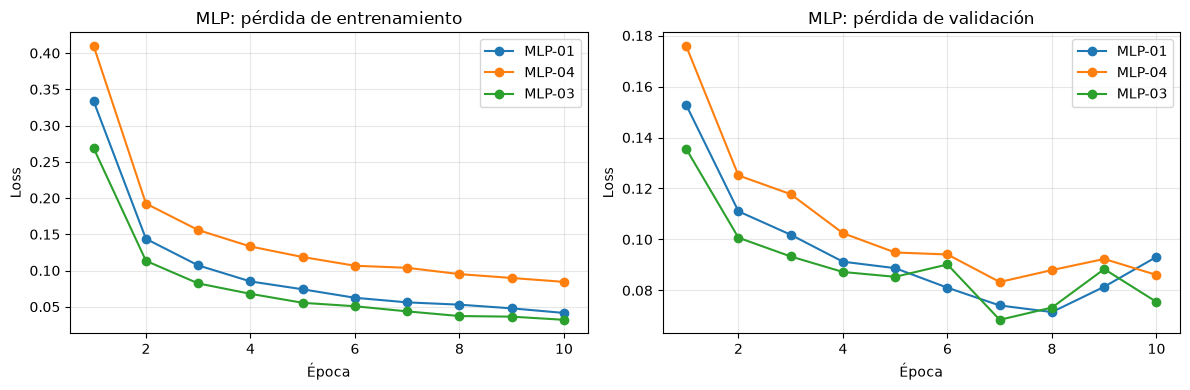

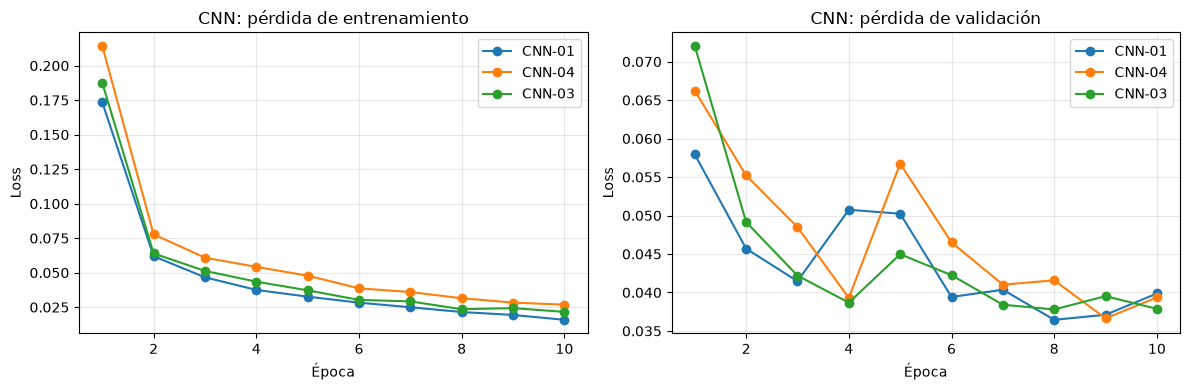

In [7]:
# Curvas de tres iteraciones por arquitectura: baseline, variación de regularización y mejor configuración.
for architecture in ('MLP', 'CNN'):
    candidates = results_df.query('architecture == @architecture').sort_values('val_f1_weighted')
    selected_ids = list(dict.fromkeys([
        f'{architecture}-01',
        f'{architecture}-04',
        candidates.iloc[-1]['id'],
    ]))
    plot_loss({exp_id: histories[exp_id] for exp_id in selected_ids}, architecture)
    plt.show()

## 7. Selección y evaluación final sobre test

Esta es la única sección que consulta test. Los pesos ya fueron elegidos con validación, por lo que esta evaluación es una estimación honesta de generalización.

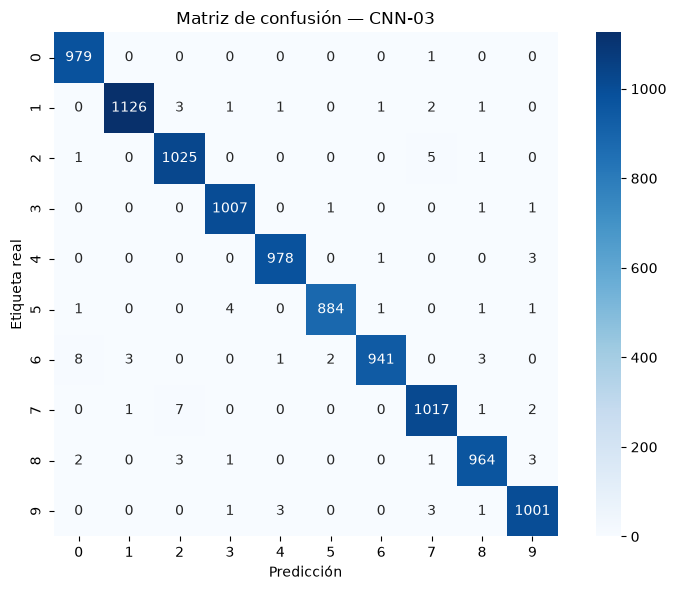

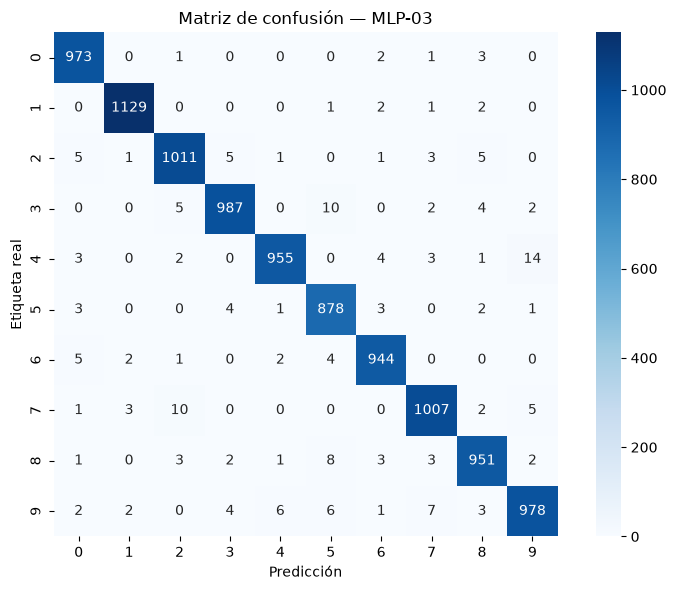

,architecture,experiment,test_accuracy,test_precision_weighted,test_recall_weighted,test_f1_weighted,trainable_parameters,training_seconds
0,CNN,CNN-03,0.9922,0.9922,0.9922,0.9922,879114,102.2667
1,MLP,MLP-03,0.9813,0.9813,0.9813,0.9813,535818,85.6968


In [8]:
best_ids = (results_df.sort_values(['architecture', 'val_f1_weighted', 'val_accuracy', 'trainable_parameters'],
                                 ascending=[True, False, False, True])
                      .groupby('architecture', as_index=False).first()[['architecture', 'id']])

criterion = nn.CrossEntropyLoss()
final_rows = []
for selection in best_ids.itertuples(index=False):
    test_metrics = evaluate(trained_models[selection.id], test_loader, criterion)
    source_row = results_df.loc[results_df['id'] == selection.id].iloc[0]
    final_rows.append({
        'architecture': selection.architecture, 'experiment': selection.id,
        'test_accuracy': test_metrics['accuracy'],
        'test_precision_weighted': test_metrics['precision_weighted'],
        'test_recall_weighted': test_metrics['recall_weighted'],
        'test_f1_weighted': test_metrics['f1_weighted'],
        'trainable_parameters': source_row['trainable_parameters'],
        'training_seconds': source_row['training_seconds'],
    })
    plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], f'Matriz de confusión — {selection.id}')

final_results = pd.DataFrame(final_rows)
display(final_results.round(4))
final_results.to_csv('resultados_finales_test.csv', index=False)

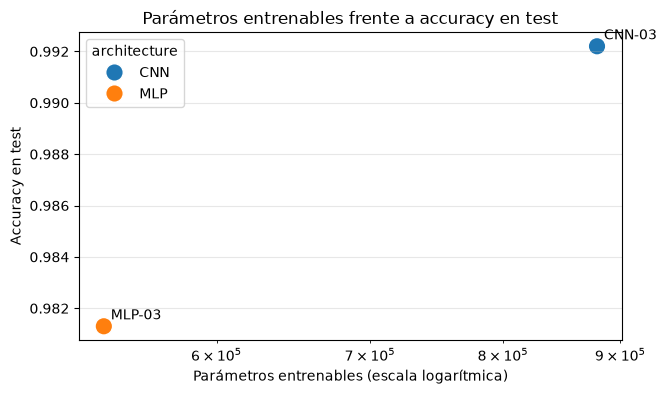

In [9]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=final_results, x='trainable_parameters', y='test_accuracy', hue='architecture', s=160)
for row in final_results.itertuples():
    plt.annotate(row.experiment, (row.trainable_parameters, row.test_accuracy), xytext=(5, 5), textcoords='offset points')
plt.xscale('log')
plt.title('Parámetros entrenables frente a accuracy en test')
plt.xlabel('Parámetros entrenables (escala logarítmica)')
plt.ylabel('Accuracy en test')
plt.grid(alpha=.3)
plt.show()

## 8. Discusión y conclusiones

Completar esta sección con base en `results_df`, las curvas y las matrices de confusión:

1. ¿Qué hiperparámetro tuvo el mayor efecto positivo y negativo para cada arquitectura? Citar las filas comparadas.
2. ¿Hubo overfitting o underfitting? Identificarlo con la separación entre las curvas de pérdida y describir la mitigación aplicada.
3. ¿La regularización (dropout, weight decay o batch normalization) mejoró la validación? Comparar configuraciones equivalentes.
4. ¿Qué arquitectura rindió mejor en test y cómo se relaciona con parámetros y el procesamiento espacial?
5. ¿Qué pares de dígitos aparecen con más frecuencia fuera de la diagonal de cada matriz de confusión?
6. Para despliegue, elegir la arquitectura que ofrezca el mejor equilibrio entre accuracy, parámetros y tiempo de entrenamiento/inferencia.

Para el PDF final: incluir la tabla condensada de iteraciones, la tabla de test, la gráfica parámetros-vs-accuracy, una síntesis de las matrices de confusión y el enlace al repositorio.